<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Feature Importance
    </h1>
  </div>
</div>

Which features actually drive a model? RiskLabAI implements the three classic
measures from de Prado:

- **MDI** (Mean Decrease Impurity) — in-sample, tree-internal; fast but optimistic,
- **MDA** (Mean Decrease Accuracy) — out-of-sample permutation importance,
- **SFI** (Single Feature Importance) — train on each feature alone.

We test them on a synthetic dataset with **known** informative, redundant, and
noise features, so we can watch each method rank the real signal — and see their
characteristic differences.

Reference: López de Prado, *Advances in Financial Machine Learning*, Ch. 8.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# --- Local source bootstrap (admitted Stage-1 methods, not yet in a PyPI release) ---
import sys
from pathlib import Path
_cands = [p / "RiskLabAI.py" for p in [Path.cwd(), *Path.cwd().parents]]
_cands.append(Path(r"C:/risklab/risklabai/RiskLabAI.py"))
for _src in _cands:
    if (_src / "RiskLabAI" / "__init__.py").exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})
from sklearn.ensemble import RandomForestClassifier

from RiskLabAI.features.feature_importance import (
    get_test_dataset,
    FeatureImportanceMDI,
    FeatureImportanceMDA,
    FeatureImportanceSFI,
    orthogonal_features,
    calculate_weighted_tau,
)
from RiskLabAI.features.feature_importance import mdi_plus_importance, conditional_predictive_impact

## 1. A dataset with known ground truth

In [2]:
x, y = get_test_dataset(n_features=15, n_informative=6, n_redundant=2,
                       n_samples=1000, random_state=1)

def feature_type(nm):
    return "informative" if nm.startswith("I_") else "redundant" if nm.startswith("R_") else "noise"

types = pd.Series([feature_type(c) for c in x.columns], index=x.columns)
n_signal = int((types != "noise").sum())
print(f"{int((types == 'informative').sum())} informative + "
      f"{int((types == 'redundant').sum())} redundant = {n_signal} signal, "
      f"{int((types == 'noise').sum())} noise")

6 informative + 2 redundant = 8 signal, 7 noise


## 2. A shared plotting helper

We sort features by importance and colour them by their true type — a good method
should pile the **informative** (green) and **redundant** (blue) features on the
left and leave **noise** (grey) on the right.

In [3]:
color_of = {"informative": "seagreen", "redundant": "steelblue", "noise": "lightgray"}

def plot_importance(importance, title):
    s = importance.sort_values(ascending=False)
    colors = [color_of[types[name]] for name in s.index]
    plt.figure(figsize=(7.6, 3.4))
    plt.bar(range(len(s)), s.values, color=colors)
    plt.xlabel("feature (ranked by importance)"); plt.ylabel("importance")
    plt.title(title); plt.tight_layout(); plt.show()

def top_signal(importance):
    top = importance.sort_values(ascending=False).index[:n_signal]
    return int((types[top] != "noise").sum())

## 3. MDI — mean decrease impurity

MDI: 8/8 of the top features are real signal


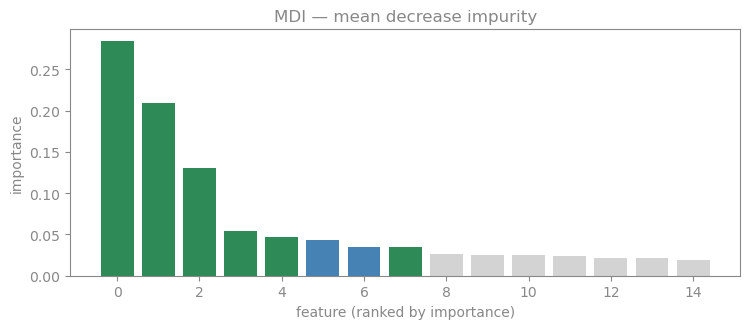

In [4]:
mdi = FeatureImportanceMDI(
    RandomForestClassifier(n_estimators=80, random_state=1)
).compute(x, y)["Mean"]
print(f"MDI: {top_signal(mdi)}/{n_signal} of the top features are real signal")
plot_importance(mdi, "MDI — mean decrease impurity")

## 4. MDA — mean decrease accuracy (permutation)

MDA permutes each feature out-of-sample. Note a known quirk: when two features are
**redundant**, permuting one barely hurts (the model leans on its twin), so MDA
tends to *understate* redundant features — a substitution effect.

MDA: 8/8 of the top features are real signal


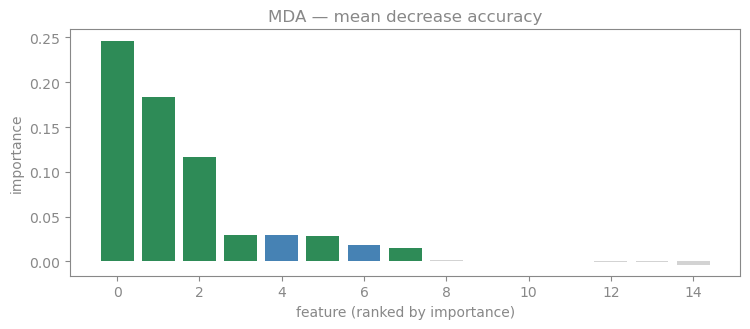

In [5]:
mda = FeatureImportanceMDA(
    RandomForestClassifier(n_estimators=80, random_state=1), n_splits=8, random_state=1
).compute(x, y)["Mean"]
print(f"MDA: {top_signal(mda)}/{n_signal} of the top features are real signal")
plot_importance(mda, "MDA — mean decrease accuracy")

## 5. SFI — single feature importance

SFI trains a model on **each feature alone**, so it is immune to substitution
effects (it never sees two features together). We score by **accuracy** — log-loss
penalises a single strong feature's overconfident OOS mistakes and mis-ranks it
below noise.

SFI: 3/8 of the top features are real signal


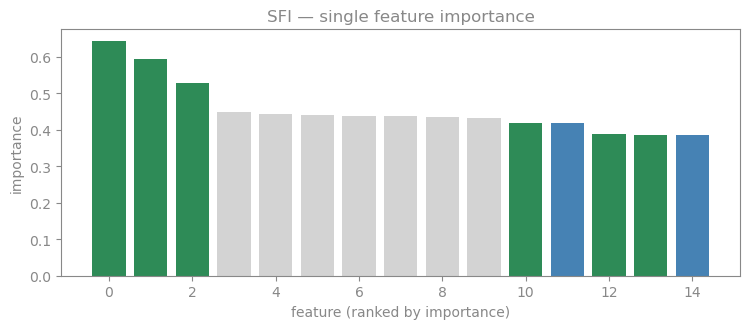

In [6]:
sfi = FeatureImportanceSFI(
    RandomForestClassifier(n_estimators=80, random_state=1), n_splits=8, scoring="accuracy"
).compute(x, y)["Mean"]
print(f"SFI: {top_signal(sfi)}/{n_signal} of the top features are real signal")
plot_importance(sfi, "SFI — single feature importance")

## 6. Orthogonal features & method agreement

Collinear (redundant) features split a model's attention. `orthogonal_features`
(PCA) builds uncorrelated features that sidestep this. The **weighted Kendall-τ**
then measures how strongly two importance rankings agree (weighting top ranks
most).

In [7]:
orth, eigen = orthogonal_features(x, variance_threshold=0.95)
print(f"PCA: {orth.shape[1]} orthogonal components capture 95% of variance "
      f"(from {x.shape[1]} raw features)")

mda_aligned = mda.reindex(mdi.index)
mda_rank = mda_aligned.rank(ascending=False).to_numpy()   # rank 1 = most important
tau = calculate_weighted_tau(mdi.to_numpy(), mda_rank)
print(f"MDI vs MDA agreement (weighted Kendall-τ): {tau:.3f}")

PCA: 12 orthogonal components capture 95% of variance (from 15 raw features)
MDI vs MDA agreement (weighted Kendall-τ): 0.917


## 7. MDI+ rejects cardinality inflation

Classic **MDI** inflates with split opportunities: a high-cardinality (continuous)
feature gets more chances to split, so a random forest credits it even when it is
pure noise. **MDI+** (Agarwal et al. 2023) recasts importance as out-of-bag partial
variance on a regularized stump model, removing that inflation.

We build a tiny problem with one informative feature plus two **noise** features, one
high-cardinality (continuous) and one low-cardinality (binary), and compare.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rng = np.random.default_rng(0); n = 800
sig = rng.standard_normal(n)
y_card = pd.Series((sig + 0.5 * rng.standard_normal(n) > 0).astype(int))
X_card = pd.DataFrame({
    "informative":    sig,
    "noise_highcard": rng.standard_normal(n),               # continuous noise
    "noise_lowcard":  rng.integers(0, 2, n).astype(float),  # binary noise
})

mdi = FeatureImportanceMDI(
    RandomForestClassifier(n_estimators=200, random_state=1)
).compute(X_card, y_card)["Mean"]
mdip = mdi_plus_importance(X_card, y_card)

pd.DataFrame({"MDI (baseline)": mdi, "MDI+": mdip}).round(3)

,MDI (baseline),MDI+
informative,0.791,0.157
noise_highcard,0.203,0.003
noise_lowcard,0.006,0.000


MDI hands the high-cardinality **noise** feature a sizeable score purely because it
offers more split points; MDI+ drives both noise features to almost zero, keeping
only the genuinely informative one.

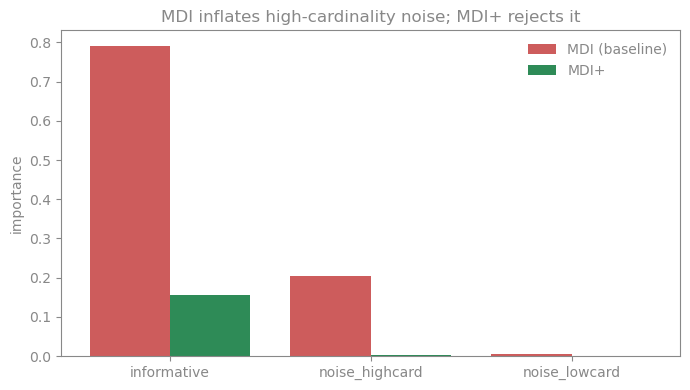

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
xpos = np.arange(len(X_card.columns))
ax.bar(xpos - 0.2, mdi.values, width=0.4, label="MDI (baseline)", color="indianred")
ax.bar(xpos + 0.2, mdip.values, width=0.4, label="MDI+", color="seagreen")
ax.set_xticks(xpos); ax.set_xticklabels(X_card.columns)
ax.set_ylabel("importance"); ax.legend()
ax.set_title("MDI inflates high-cardinality noise; MDI+ rejects it")
plt.tight_layout(); plt.show()

## 8. CPI: a statistically valid significance test

MDA tells you a feature *seems* important but offers no test of whether that is more
than chance. **CPI** (Conditional Predictive Impact, Watson-Wright 2021) gives a
performance-based importance with a calibrated **p-value**, so you can say a feature
matters at a stated significance level. Here the informative feature is significant
while the noise features are not.

In [10]:
cpi = conditional_predictive_impact(X_card, y_card)
print(cpi.round(4))
print("\ninformative p-value:", f"{cpi.loc['informative', 'p_value']:.4f}",
      "  -> significant" if cpi.loc["informative", "p_value"] < 0.05 else "")
for f in ("noise_highcard", "noise_lowcard"):
    print(f"{f} p-value:", f"{cpi.loc[f, 'p_value']:.4f}",
          "  -> not significant" if cpi.loc[f, "p_value"] >= 0.05 else "")

                importance  p_value
informative         1.0372   0.0000
noise_highcard     -0.0040   0.7055
noise_lowcard       0.0077   0.1406

informative p-value: 0.0000   -> significant
noise_highcard p-value: 0.7055   -> not significant
noise_lowcard p-value: 0.1406   -> not significant


## Takeaways

- MDI is fast but in-sample and **inflates with feature cardinality**; MDA is
  out-of-sample but has no significance test; SFI scores each feature alone.
- Prefer **MDI+** when features are noisy, high-cardinality, or mixed-type: it
  rejects the noise/cardinality inflation that MDI suffers (here the high-cardinality
  noise feature's score collapses under MDI+) and converges to MDI when features are
  orthogonal and high-SNR.
- Prefer **CPI** when you need a statistically valid test of whether a feature
  matters (MDA has none): it gives a conditional, performance-based importance with a
  calibrated p-value.
- Orthogonalizing features first reduces substitution effects; method **agreement**
  across MDI/MDA/SFI/MDI+ is the strongest signal a feature is genuinely informative.

`FeatureImportanceMDI/MDA/SFI`, `mdi_plus_importance`, and
`conditional_predictive_impact` all come from `RiskLabAI.features.feature_importance`.